<a href="https://colab.research.google.com/github/AdrianFLG/procesamiento_de_datos/blob/main/2_escalado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Escalado
Conjunto de datos: iris (incluido en sklearn)
Este conjunto de datos es compacto y perfecto para demostrar técnicas de escalado.

In [1]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cargar el conjunto de datos
iris = load_iris(as_frame=True)
data = iris.data

In [3]:
# Visualizar las estadísticas iniciales
print("Estadísticas iniciales:")
data.describe()

Estadísticas iniciales:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
data_minmax = pd.DataFrame(minmax_scaler.fit_transform(data), columns=data.columns)

In [5]:
# Aplicar StandardScaler
standard_scaler = StandardScaler()
data_standard = pd.DataFrame(standard_scaler.fit_transform(data), columns=data.columns)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre las estadísticas originales y las del escalado MinMax?


In [6]:
# Comparamos las estadísticas descriptivas
print("Estadísticas Originales (Resumen):")
print(data.describe().loc[['min', 'max', 'mean']])

print("\nEstadísticas con MinMaxScaler (Resumen):")
print(data_minmax.describe().loc[['min', 'max', 'mean']])

Estadísticas Originales (Resumen):
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
min            4.300000          2.000000              1.000          0.100000
max            7.900000          4.400000              6.900          2.500000
mean           5.843333          3.057333              3.758          1.199333

Estadísticas con MinMaxScaler (Resumen):
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
min            0.000000          0.000000           0.000000          0.000000
max            1.000000          1.000000           1.000000          1.000000
mean           0.428704          0.440556           0.467458          0.458056


La principal diferencia es el rango. En los datos originales, las variables tienen mínimos de 0.1 y máximos de hasta 7.9 (unidades en cm). Tras el escalado MinMax, todas las variables quedan estrictamente acotadas entre 0.0 y 1.0, eliminando la disparidad de magnitudes entre características pero conservando la relación proporcional entre los datos

### 2. Crea una gráfica de la distribución de la variable 'sepal length (cm)' antes y después del escalado.

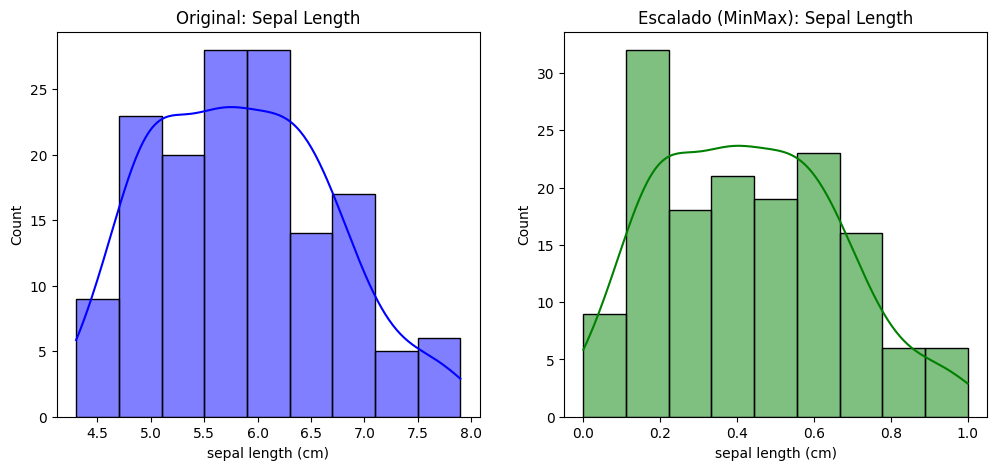

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el lienzo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Antes del escalado
sns.histplot(data['sepal length (cm)'], kde=True, color='blue', ax=ax1)
ax1.set_title('Original: Sepal Length')

# Después del escalado (puedes usar data_minmax o data_standard)
sns.histplot(data_minmax['sepal length (cm)'], kde=True, color='green', ax=ax2)
ax2.set_title('Escalado (MinMax): Sepal Length')

plt.show()

### 3. Crea una gráfica de dispersión entre 'sepal length (cm)' y 'sepal width (cm)' con los datos escalados por StandardScaler.

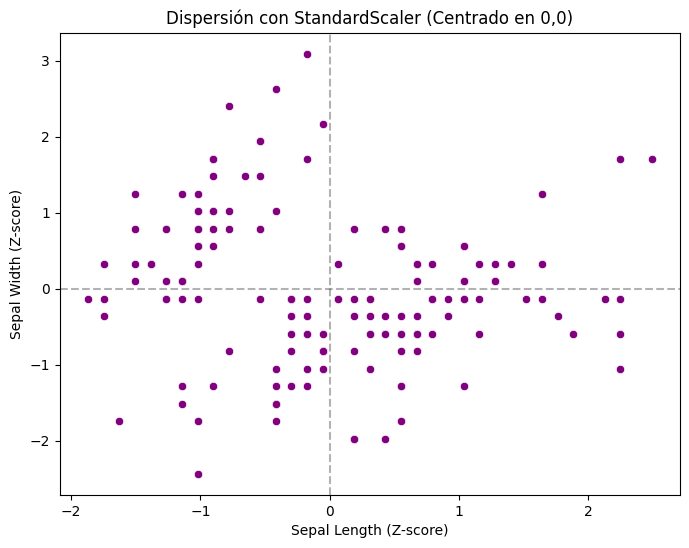

In [8]:
plt.figure(figsize=(8, 6))

# Usamos la variable 'data_standard' que ya creaste arriba
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', data=data_standard, color='purple')

# Dibujamos líneas en el origen (0,0) para resaltar la estandarización
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)

plt.title('Dispersión con StandardScaler (Centrado en 0,0)')
plt.xlabel('Sepal Length (Z-score)')
plt.ylabel('Sepal Width (Z-score)')
plt.show()

### 4. ¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?

Para el conjunto de datos Iris, la técnica más adecuada suele ser StandardScaler. Esto se debe a que las medidas biológicas (como largo y ancho de pétalos) tienden a seguir una distribución normal. Además, si planeamos usar modelos como Redes Neuronales (Perceptrones) o máquinas de soporte vectorial, la estandarización ayuda a que el algoritmo converja más rápido al tener datos centrados en cero con una varianza constante